# Photoresistor frequency check for an SSVEP session

Validates that the frequency actually displayed on screen matches the target SSVEP
flicker, using an Arduino + photoresistor sampled by `record_photosensor.py`.

**Inputs**
- a session folder from `ssvep-bci` or `psychopy-ssvep` (`events.jsonl` + `experiment-config.yaml`),
- `light_amp.csv` produced by `record_photosensor.py`.

**Clock sync.** The recorder timestamps every sample with `time.perf_counter()`, the
same system-wide monotonic clock the app uses for the `monotonic_timestamp` in
`events.jsonl`, so trial
onsets align to light samples directly. The recorder also writes a wall-clock column
so the notebook can cross-validate the alignment.

The equivalent headless runner is `run_check.py`.


In [1]:
# --- configuration ------------------------------------------------------------
SESSION = "../../ssvep-bci/sessions/<session-folder>"  # or a psychopy-ssvep session
LIGHT_CSV = "../light_amp.csv"                       # from record_photosensor.py
LATENCY = 0.07                                     # serial-latency fudge (s)
TOLERANCE_HZ = 0.25                                # max |detected - target| for a PASS

import sys
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np

# make photosensor_check importable when launched from the repo root or notebooks/
for _candidate in (Path.cwd(), Path.cwd().parent, Path.cwd().parents[1]):
    if (_candidate / "photosensor_check").is_dir() and str(_candidate) not in sys.path:
        sys.path.insert(0, str(_candidate))
        break

import photosensor_check as pc


In [2]:
# --- load trial timing + light data -------------------------------------------
trials, DURATION = pc.load_session_trials(SESSION)
frame = pc.load_light_amp(LIGHT_CSV)
sfreq, frame = pc.retime_uniform(frame)   # constant-rate Arduino -> uniform timeline

diagnostics = pc.sampling_diagnostics(frame)
if diagnostics["bursty"]:
    print(f"note: serial reads were bursty; median-rate "
          f"{diagnostics['median_rate_hz']:.0f} Hz vs span-rate "
          f"{diagnostics['span_rate_hz']:.0f} Hz -- using span-rate on a uniform grid")

quality = pc.signal_quality(frame["light_amp"].to_numpy())
if not quality["has_contrast"]:
    print(f"WARNING: light_amp has almost no contrast (p05={quality['p05']:.0f}, "
          f"p95={quality['p95']:.0f}); the sensor may be saturated or not on the stimulus")

print(f"sample rate ~ {sfreq:.0f} Hz")
print(f"{len(trials)} trials, {len(frame):,} light samples")
print(f"frequencies under test: {sorted({t.frequency_hz for t in trials})}")

sample rate ~ 1574 Hz
3 trials, 47,346 light samples
frequencies under test: [8.25]


In [3]:
# --- clock-sync verification --------------------------------------------------
# Both the app (events.jsonl) and the recorder (light_amp.csv) carry wall-UTC and
# monotonic times. If both processes share one time base, the wall-clock-derived
# sample index for each onset lands at onset_monotonic + ~latency, consistently.
alignment = pc.verify_alignment(frame, trials)
alignment
assert alignment['residual_ms'].std() < 5.0, "clock mismatch: check wall/monotonic times"

In [4]:
# --- cut one light waveform per trial -----------------------------------------
segments = pc.segment_trials(frame, trials, latency=LATENCY, default_duration=DURATION)

empty = [s for s in segments if len(s.x) == 0]
if empty:
    print(f"WARNING: {len(empty)} empty windows -- clock mismatch or recorder stopped early")
    for s in empty:
        print("  ", s.trial.presentation_id, "onset", s.trial.onset_monotonic)

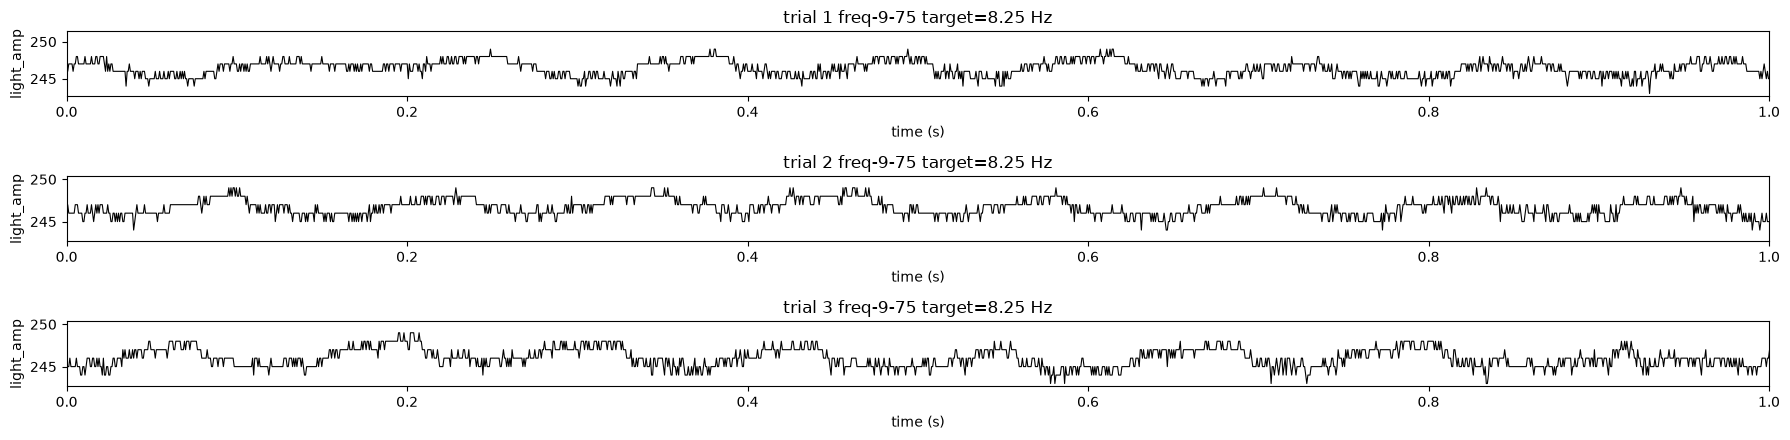

In [5]:
# --- time-domain check (frame-skips) -------------------------------------------
# Uniform on/off pulse widths = clean timing. One ~2x-wide pulse = a frame-skip.
fig, axes = plt.subplots(len(segments), 1, figsize=(18, 1.5 * len(segments)), squeeze=False)
for ax, seg in zip(axes[:, 0], segments):
    lo = float(seg.x.min())
    hi = float(seg.x.max())
    mid = 0.5 * (lo + hi)
    amp = 0.5 * (hi - lo)
    ideal = mid + amp * pc.ideal_waveform(seg.trial, seg.t)
    ax.plot(seg.t - seg.t[0], seg.x, color='black', lw=1.2, label='measured')
    ax.plot(seg.t - seg.t[0], ideal, color='#e67e22', lw=1.0, alpha=0.9, label=f'ideal {seg.trial.waveform}')
    ax.set_xlim(0, seg.t[-1] - seg.t[0])
    margin = (hi - lo) * 0.06 if hi > lo else 1.0
    ax.set_ylim(lo - margin, hi + margin)
    ax.set_title(f"trial {seg.trial.trial_number} {seg.trial.stimulus_id} "
                 f"target={seg.trial.frequency_hz:.2f} Hz")
    ax.set_xlabel("time (s)"); ax.set_ylabel("light_amp")
    ax.legend(loc='upper right', fontsize=8)
fig.tight_layout(); plt.show()

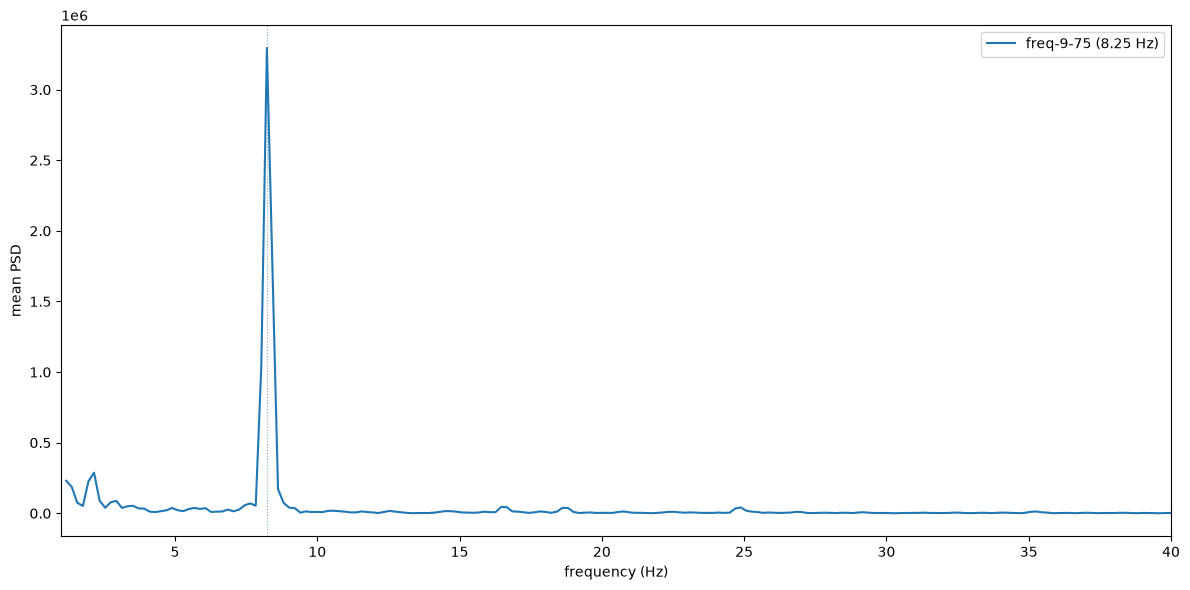

In [6]:
# --- frequency-domain check (FFT peak + square-wave harmonics) -----------------
nonempty = [s for s in segments if len(s.x) > 0]
nfft = max(len(s.x) for s in nonempty) if nonempty else 1
fig, ax = plt.subplots(figsize=(12, 6))
by_class = {}
for seg in nonempty:
    key = (seg.trial.stimulus_id, seg.trial.frequency_hz)
    freqs, psd = pc.power_spectrum(seg.x, sfreq, nfft=nfft)
    by_class.setdefault(key, []).append((freqs, psd))
for (stimulus_id, target), spectra in sorted(by_class.items()):
    freqs = spectra[0][0]
    mean = np.mean([p for _, p in spectra], axis=0)
    band = (freqs >= 1) & (freqs <= 40)
    ax.plot(freqs[band], mean[band], label=f"{stimulus_id} ({target:.2f} Hz)")
    peak = pc.detect_peak(freqs, mean)
    if peak is not None:
        ax.axvline(peak, ls=':', lw=0.8, alpha=0.6)
ax.set_xlim(1, 40); ax.set_xlabel("frequency (Hz)"); ax.set_ylabel("mean PSD")
ax.legend(); fig.tight_layout(); plt.show()

In [7]:
# --- per-trial summary ---------------------------------------------------------
summary = pc.summarize(segments, sfreq, tolerance_hz=TOLERANCE_HZ)
summary

,trial_number,presentation_id,stimulus_id,target_hz,detected_hz,delta_hz,samples,duration_s,frame_skips,harmonic_3f,harmonic_5f,pass
0,1,presentation-0001,freq-9-75,8.25,8.228954,-0.021046,8036,5.103294,12,False,False,True
1,2,presentation-0002,freq-9-75,8.25,8.236128,-0.013872,8029,5.098848,6,False,False,True
2,3,presentation-0003,freq-9-75,8.25,8.237154,-0.012846,8028,5.098213,7,False,False,True


In [8]:
print(f"sample rate ~ {sfreq:.0f} Hz")
print(f"PASS {summary['pass'].sum()} / FAIL {(~summary['pass']).sum()}")
print("median |delta| = %.4f Hz" % summary['delta_hz'].dropna().abs().median())
print("total frame-skips = %d" % summary['frame_skips'].sum())
print()
print(summary.loc[~summary['pass'], ['trial_number', 'stimulus_id', 'target_hz',
                                     'detected_hz', 'delta_hz', 'frame_skips']])

sample rate ~ 1574 Hz
PASS 3 / FAIL 0
median |delta| = 0.0139 Hz
total frame-skips = 25

Empty DataFrame
Columns: [trial_number, stimulus_id, target_hz, detected_hz, delta_hz, frame_skips]
Index: []


## Interpretation

- **Frequency identity:** each trial's `detected_hz` should sit within one FFT bin
  (~0.2 Hz for 5 s windows) of `target_hz`. Larger systematic errors mean the
  monitor is not rendering the requested frequency.
- **Frame-skips:** a doubled pulse in the time-domain strip is a skipped frame; it
  may not move the FFT peak, which is why the time-domain check is mandatory.
- **Harmonics:** `harmonic_3f` / `harmonic_5f` confirm the flicker is a square wave.
- **Empty windows:** recorder stopped before the trial, or a clock mismatch.

## Practical notes
- FFT resolution = 1 / window seconds; for closely spaced frequencies prefer the
  long ssvep-bci trials (4-5 s) over the 1 s strip shown above.
- `sfreq` is measured per recording (median inter-sample time), never assumed.
- Serial latency (~30-70 ms) exists between screen frame and PC timestamp; `LATENCY`
  skips it at onset, and the alignment table above should show a consistent residual.
- Frequency and timing are two different checks: FFT for identity, pulse widths for
  frame-skips. Do both.